In [1]:

import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

from scipy.constants import golden

from sklearn import tree
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, zero_one_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from splitting_criterion import Entropy, StandardDeviation
from tree_predictor import TreePredictor
from utils import load_mushroom_dataset, manual_gridsearch

plt.style.use( 'fivethirtyeight' )
plt.rc( 'figure', figsize=( 5., 5. / golden ))

plt.rc( 'axes', labelsize='small' )
plt.rc( 'legend', fontsize='x-small' )
plt.rc( 'xtick', labelsize='xx-small' )
plt.rc( 'ytick', labelsize='xx-small' )


In [2]:
X, y, categorical_features = load_mushroom_dataset()

## Scatter plot

In [5]:

for feature in categorical_features:
  encoder = LabelEncoder()
  encoder.fit( X[ :, feature ] )
  X[ :, feature ] = encoder.transform( X[ :, feature ] )


In [6]:

pca = PCA( n_components=2 )
X_new = pca.fit_transform( X )


In [7]:

gen = np.random.default_rng( 42 )
# X_new_sample = gen.choice( X_new, size=10**3, replace=False )
# We also need to extract the corresponding labels

indices = gen.choice( len( X_new ), 1000, replace=False )
X_sample = X_new[ indices ]
y_sample = y[ indices ]


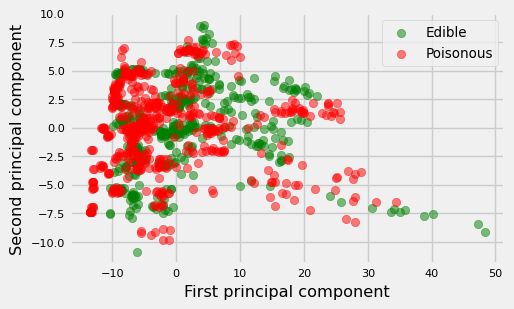

In [9]:

plt.scatter( X_sample[ :, 0][ y_sample == 0 ],
             X_sample[ :, 1 ][ y_sample == 0 ], c='green', alpha=.5,
             label='Edible' )

plt.scatter( X_sample[ :, 0 ][ y_sample == 1 ],
             X_sample[ :, 1 ][ y_sample == 1 ], c='red', alpha=.5,
             label='Poisonous' )

plt.xlabel( 'First principal component' )
plt.ylabel( 'Second principal component' )
plt.legend()
# plt.tick_params( labelsize='xx-small' )

plt.show()


## Comparisons with sklearn's tree predictor

In [3]:
X, y, categorical_features = load_mushroom_dataset()

In [24]:

for feature in categorical_features:
  encoder = LabelEncoder()
  encoder.fit( X[ :, feature ] )
  X[ :, feature ] = encoder.transform( X[ :, feature ] )


In [25]:

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=.33, random_state=42 )


In [39]:

clf = tree.DecisionTreeClassifier( min_impurity_decrease=0.07 )
clf = clf.fit( X_train, y_train )

y_pred = clf.predict( X_test )


In [41]:

# Always predicts the majority label in the train set
print( '(sklearn tree) Gini, minimum information gain decrease 0.07, 0-1 loss '
       'on test set:', zero_one_loss( y_test, y_pred ) )


(sklearn tree) Gini, minimum information gain decrease 0.07, 0-1 loss on test set: 0.43657174001907617


In [5]:

clf = TreePredictor(
  categorical_features,
  min_impurity_decrease=0.07,
  n_unique_values=2**9 )

clf.fit( X_train, y_train )


-- Attribute selected: cap-surface, with set/threshold ('e', 'g', 'h', 's', 'y') and gain 0.07401251017113464
-- Attribute selected: gill-color, with set/threshold ('f', 'n', 'r', 'u', 'y') and gain 0.11318870369946676
-- Attribute selected: gill-attachment, with set/threshold ('d', 'f', 's') and gain 0.1997601735967618
-- Attribute selected: cap-diameter, with set/threshold 5.33 and gain 0.1889373804976091
-- Attribute selected: ring-type, with set/threshold ('l', 'r') and gain 0.1893348039569319
-- Attribute selected: gill-spacing, with set/threshold ('c',) and gain 0.20018819469752186
-- Attribute selected: stem-width, with set/threshold 10.35 and gain 0.026330174927113696
information gain 0.026330174927113696 too small, not splitting
-- Attribute selected: cap-shape, with set/threshold ('c',) and gain 0.11891633412715641
-- Attribute selected: ring-type, with set/threshold ('z',) and gain 0.01968826950661059
information gain 0.01968826950661059 too small, not splitting
-- Attribute

In [6]:
print( clf )

Node:
  Decision: Feature cap-surface in ('e', 'g', 'h', 's', 'y')
  Left:
    Node:
      Decision: Feature gill-color in ('f', 'n', 'r', 'u', 'y')
      Left:
        Node:
          Decision: Feature gill-attachment in ('d', 'f', 's')
          Left:
            Leaf: Label=1
          Right:
            Node:
              Decision: Feature cap-diameter <= 5.33
              Left:
                Node:
                  Decision: Feature ring-type in ('l', 'r')
                  Left:
                    Leaf: Label=0
                  Right:
                    Node:
                      Decision: Feature gill-spacing in ('c',)
                      Left:
                        Leaf: Label=1
                      Right:
                        Leaf: Label=0
              Right:
                Node:
                  Decision: Feature cap-shape in ('c',)
                  Left:
                    Leaf: Label=1
                  Right:
                    Leaf: Label=0
      Rig

In [6]:
y_pred = clf.predict( X_test )

In [7]:

print( 'Gini, minimum information gain decrease 0.07, 0-1 loss on test set:',
       zero_one_loss( y_test, y_pred ) )


Gini, minimum information gain decrease 0.07, 0-1 loss on test set: 0.11718217740836623


In [7]:
y_pred = clf.predict( X_train )

In [8]:

print( 'Gini, minimum information gain decrease 0.07, 0-1 loss on train set:',
       zero_one_loss( y_train, y_pred ) )


Gini, minimum information gain decrease 0.07, 0-1 loss on train set: 0.1142281879194631


In [9]:

#   Let's shuffle the train labels and see how the predictor behaves: it should
# still have a training error of zero, and a test error of approximately 50%

gen = np.random.default_rng( 42 )
y_train_shuffled = gen.shuffle( y_train )


In [11]:

# common_labels = 0
# for ix in range( len( y_train ) ):
#   if y_train_shuffled[ ix ] == y_train[ ix ]:
#     common_labels = common_labels + 1

# print( f'Common labels: {common_labels / len( y_train ) * 100:.2f}%' )


TypeError: 'NoneType' object is not subscriptable

In [12]:

# np.Generator.shuffle happens in-place.. use np.Generator.permutation next
y_train


array([0, 1, 1, ..., 0, 1, 1], shape=(14900,))

In [13]:

# Shuffled train labels
tp_wrong = TreePredictor( categorical_features, max_depth=20 )
tp_wrong.fit( X_train, y_train )

y_pred = tp_wrong.predict( X_test )


In [14]:

print( '(Wrong tree) Gini, maximum depth 20, 0-1 loss on test set:',
       zero_one_loss( y_test, y_pred ) )


(Wrong tree) Gini, maximum depth 20, 0-1 loss on test set: 0.4685924512876414


In [15]:

y_pred = tp_wrong.predict( X_train )

print( 'Gini, maximum depth 20, 0-1 loss on train set:',
       zero_one_loss( y_train, y_pred ) )


Gini, maximum depth 20, 0-1 loss on test set: 0.1832885906040268


In [20]:

# Let's see how the sklearn tree does
for feature in categorical_features:
  # print( 'Encoding', feature_names[ feature ] )
  encoder = LabelEncoder()
  encoder.fit( X[ :, feature ] )
  # print( 'Transforming', feature_names[ feature ] )
  X[ :, feature ] = encoder.transform( X[ :, feature ] )

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=.33, random_state=42 )

clf = tree.DecisionTreeClassifier( max_depth=20 )


In [26]:

y_train_shuffled = gen.permutation( y_train )
clf = clf.fit( X_train, y_train_shuffled )

y_pred = clf.predict( X_test )


In [27]:

# Shuffled train labels
print( '(sklearn tree) Gini, maximum depth 20, 0-1 loss on test set:',
       zero_one_loss( y_test, y_pred ) )


(sklearn tree) Gini, maximum depth 20, 0-1 loss on test set: 0.46954625970840713


In [28]:

y_pred = clf.predict( X_train )

print( '(sklearn tree) Gini, maximum depth 20, 0-1 loss on train set:',
       zero_one_loss( y_train, y_pred ) )


(sklearn tree) Gini, maximum depth 20, 0-1 loss on train set: 0.47409395973154367


In [32]:

#   Ok, then maybe a depth of 20 isn't enough to explain the dataset with
# shuffled labels. This could be why the training error of the custom tree
# isn't zero

X, y, categorical_features = load_mushroom_dataset()
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=.33, random_state=42 )

y_test_shuffled = gen.permutation( y_test )

common_labels = 0
for ix in range( len( y_test ) ):
  if y_test[ ix ] == y_test_shuffled[ ix ]:
    common_labels = common_labels + 1

print( f'Proportion of labels in common: {common_labels / len( y_test ) * 100:.2f}%' )


Proportion of labels in common: 51.57%


C:\Users\Lucilfer\AppData\Local\Temp\ipykernel_5364\3979478381.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({ 'e': 0, 'p': 1 })


In [33]:

tp = TreePredictor( categorical_features, max_depth=20 )
tp.fit( X_train, y_train )


In [38]:

# Shuffled test labels
y_pred = tp.predict( X_train )
print( '(Wrong test labels) Gini, max depth 20, 0-1 loss on training set:',
       zero_one_loss( y_train, y_pred ) )

y_pred = tp.predict( X_test )
print( '(Wrong test labels) Gini, max depth 20, 0-1 loss on test set:',
       zero_one_loss( y_test_shuffled, y_pred ) )


(Wrong test labels) Gini, max depth 20, 0-1 loss on training set: 0.0
(Wrong test labels) Gini, max depth 20, 0-1 loss on test set: 0.4843984194031884


In [39]:

X, y, categorical_features = load_mushroom_dataset()
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=.33, random_state=42 )

y_train_shuffled = gen.permutation( y_train )
y_test_shuffled = gen.permutation( y_test )

wrong_tp = TreePredictor( categorical_features, max_depth=20 )
wrong_tp.fit( X_train, y_train_shuffled )


C:\Users\Lucilfer\AppData\Local\Temp\ipykernel_5364\3979478381.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({ 'e': 0, 'p': 1 })


In [41]:

# Shuffled train and test labels
y_pred = wrong_tp.predict( X_train )
print( '(Wrong tree) Gini, max depth 20, 0-1 loss on training set:',
       zero_one_loss( y_train_shuffled, y_pred ) )

y_pred = wrong_tp.predict( X_test )
print( '(Wrong test labels) Gini, max depth 20, 0-1 loss on test set:',
       zero_one_loss( y_test_shuffled, y_pred ) )


(Wrong tree) Gini, max depth 20, 0-1 loss on training set: 0.236241610738255
(Wrong test labels) Gini, max depth 20, 0-1 loss on test set: 0.48153699414089113


## Linear models

In [44]:

# To check if the dataset can be easily explained
from sklearn.svm import LinearSVC

X, y, _ = load_mushroom_dataset()

for feature in categorical_features:
  # print( 'Encoding', feature_names[ feature ] )
  encoder = LabelEncoder()
  encoder.fit( X[ :, feature ] )
  # print( 'Transforming', feature_names[ feature ] )
  X[ :, feature ] = encoder.transform( X[ :, feature ] )

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=.33, random_state=42 )

clf = LinearSVC()
clf = clf.fit( X_train, y_train )
y_pred = clf.predict( X_test )
print( '(Linear SVC) 0-1 loss on test set: ', zero_one_loss( y_test, y_pred ) )


C:\Users\Lucilfer\AppData\Local\Temp\ipykernel_5364\3979478381.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({ 'e': 0, 'p': 1 })


(Linear SVC) 0-1 loss on test set:  0.3064450197574602


In [17]:

from sklearn.linear_model import Perceptron

X, y, categorical_features  = load_mushroom_dataset()
for feature in categorical_features:
  # print( 'Encoding', feature_names[ feature ] )
  encoder = LabelEncoder()
  encoder.fit( X[ :, feature ] )
  # print( 'Transforming', feature_names[ feature ] )
  X[ :, feature ] = encoder.transform( X[ :, feature ] )

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=.33, random_state=42 )

clf = Perceptron( tol=1e-3, random_state=42 )
clf.fit( X_train, y_train )
clf.score( X_test, y_test )


0.4514238997138575

## Scaled entropy

In [3]:

X, y, categorical_features = load_mushroom_dataset()
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=.33, random_state=42 )


In [4]:

clf = TreePredictor(
  categorical_features, splitting_criterion=Entropy(), min_samples_split=4096 )

clf.fit( X_train, y_train )


-- Attribute selected: cap-surface, with set/threshold ('e', 'g', 'h', 's', 'y') and gain 0.055397676973331755
-- Attribute selected: gill-color, with set/threshold ('f', 'n', 'r', 'u', 'y') and gain 0.0890003258751369
Only 2410 samples, not splitting
-- Attribute selected: stem-height, with set/threshold 3.43 and gain 0.08026620560884778
Only 557 samples, not splitting
-- Attribute selected: cap-color, with set/threshold ('e', 'p', 'r') and gain 0.06950154678321252
Only 355 samples, not splitting
Only 3970 samples, not splitting
-- Attribute selected: gill-color, with set/threshold ('e', 'g', 'k', 'n', 'p', 'r', 'u', 'w', 'y') and gain 0.05883013798121528
-- Attribute selected: stem-color, with set/threshold ('e', 'k', 'l', 'p', 'r', 'u', 'y') and gain 0.037769829678473754
Only 1761 samples, not splitting
-- Attribute selected: cap-color, with set/threshold ('g', 'k', 'l', 'p', 'u') and gain 0.041893774270737094
Only 374 samples, not splitting
-- Attribute selected: gill-attachment, w

In [7]:
print( clf )

Node:
  Decision: Feature cap-surface in ('e', 'g', 'h', 's', 'y')
  Left:
    Node:
      Decision: Feature gill-color in ('f', 'n', 'r', 'u', 'y')
      Left:
        Leaf: Label=1
      Right:
        Node:
          Decision: Feature stem-height <= 3.43
          Left:
            Leaf: Label=1
          Right:
            Node:
              Decision: Feature cap-color in ('e', 'p', 'r')
              Left:
                Leaf: Label=1
              Right:
                Leaf: Label=0
  Right:
    Node:
      Decision: Feature gill-color in ('e', 'g', 'k', 'n', 'p', 'r', 'u', 'w', 'y')
      Left:
        Node:
          Decision: Feature stem-color in ('e', 'k', 'l', 'p', 'r', 'u', 'y')
          Left:
            Leaf: Label=1
          Right:
            Node:
              Decision: Feature cap-color in ('g', 'k', 'l', 'p', 'u')
              Left:
                Leaf: Label=0
              Right:
                Node:
                  Decision: Feature gill-attachment in 

In [5]:
y_pred = clf.predict( X_test )

In [6]:

print( 'Entropy, minimum samples for split 4096, 0-1 loss on test set:',
       zero_one_loss( y_test, y_pred ) )


Entropy, minimum samples for split 4096, 0-1 loss on test set: 0.16419130671753646


In [19]:
y_pred = clf.predict( X_train )

In [20]:

print( 'Entropy, minimum samples for split 4096, 0-1 loss on train set:',
       zero_one_loss( y_train, y_pred ) )


Entropy, minimum samples for split 4096, 0-1 loss on train set: 0.16080536912751675


## Standard deviation

In [8]:

X, y, categorical_features = load_mushroom_dataset()
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=.33, random_state=42 )


In [9]:

clf = TreePredictor(
  categorical_features, splitting_criterion=StandardDeviation(),
  max_depth=5 )

clf.fit( X_train, y_train )


-- Attribute selected: stem-color, with set/threshold ('e', 'g', 'n', 'o', 'w', 'y') and gain 0.048564051894988636
-- Attribute selected: cap-surface, with set/threshold ('d', 'i', 'k', 't') and gain 0.03837386015645966
-- Attribute selected: ring-type, with set/threshold ('e', 'z') and gain 0.05580967215440902
-- Attribute selected: gill-attachment, with set/threshold ('p', 's') and gain 0.0391863220542778
-- Attribute selected: cap-color, with set/threshold ('e', 'n', 'r', 'w', 'y') and gain 0.049969538592880114
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
-- Attribute selected: cap-diameter, with set/threshold 1.66 and gain 0.050544806989984814
-- Attribute selected: cap-surface, with set/threshold ('y',) and gain 0.13834199607222175
-- Attribute selected: gill-color, with set/threshold ('e', 'n', 'o', 'r', 'u', 'y') and gain 0.05866302537192952
-- Attribute selected: cap-surface, with set

In [12]:
print( clf )

Node:
  Decision: Feature stem-color in ('e', 'g', 'n', 'o', 'w', 'y')
  Left:
    Node:
      Decision: Feature cap-surface in ('d', 'i', 'k', 't')
      Left:
        Node:
          Decision: Feature ring-type in ('e', 'z')
          Left:
            Leaf: Label=1
          Right:
            Node:
              Decision: Feature gill-attachment in ('p', 's')
              Left:
                Leaf: Label=0
              Right:
                Node:
                  Decision: Feature cap-color in ('e', 'n', 'r', 'w', 'y')
                  Left:
                    Leaf: Label=1
                  Right:
                    Leaf: Label=0
      Right:
        Node:
          Decision: Feature cap-diameter <= 1.66
          Left:
            Node:
              Decision: Feature cap-surface in ('y',)
              Left:
                Leaf: Label=0
              Right:
                Leaf: Label=1
          Right:
            Node:
              Decision: Feature gill-color in ('e

In [10]:
y_pred = clf.predict( X_test )

In [11]:

print( 'Standard deviation, maximum depth 5, 0-1 loss on test set:',
       zero_one_loss( y_test, y_pred ) )


Standard deviation, maximum depth 5, 0-1 loss on test set: 0.14388881318980784


In [30]:
y_pred = clf.predict( X_train )

In [31]:

print( 'Standard deviation, maximum depth 5, 0-1 loss on training set:',
       zero_one_loss( y_train, y_pred ) )


Standard deviation, maximum depth 5, 0-1 loss on training set: 0.14140939597315438


## Hyperparameter tuning

In [34]:

# parameters = { 'max_depth': [ 5, 7, 9, 11, 13, 15 ],
#                'min_samples_split': [ 2, 10, 100, 1000, 2000, 4000 ],
#                'min_impurity_decrease': [ .0, .025, .05, .1, .15, .2 ] }

# tp = TreePredictor( categorical_features )
# clf = GridSearchCV( tp, parameters, scoring='accuracy' )
# clf.fit( X, y )


TypeError: Cannot clone object '<tree_predictor.TreePredictor object at 0x0000023EFF72F570>' (type <class 'tree_predictor.TreePredictor'>): it does not seem to be a scikit-learn estimator as it does not implement a 'get_params' method.

In [14]:

parameters = {
  'max_depth': [ 4 ],
  'min_samples_split': [ 2048, 1024, 512, 128, 64, 32, 8, 2 ],
  'min_impurity_decrease': [ 0.07, 0.06, 0.02, 0.01, 0.0 ] }

res = manual_gridsearch( X, y, parameters )


-- Current parameters: max_depth = 4, min_samples_split = 2048, min_impurity_decrease = 0.07
information gain 0.06178284007256429 too small, not splitting
Only 796 samples, not splitting
Only 1088 samples, not splitting
Current depth 4 greater than or equal to maximum depth, not splitting
-- Score on fold 0: 0.7911776608660461
-- Time required to train 312.1
information gain 0.06779396428039841 too small, not splitting
Only 304 samples, not splitting
information gain 0.06226587688013693 too small, not splitting
Only 1718 samples, not splitting
-- Score on fold 1: 0.7687171185754755
-- Time required to train 288.51
information gain 0.06188577169527265 too small, not splitting
Only 753 samples, not splitting
Only 1210 samples, not splitting
information gain 0.06584812856547362 too small, not splitting
-- Score on fold 2: 0.7786321327397815
-- Time required to train 288.22
-- Current parameters: max_depth = 4, min_samples_split = 2048, min_impurity_decrease = 0.06
information gain 0.02426

KeyboardInterrupt: 

In [4]:
res = manual_gridsearch( X, y )

-- Current parameters: max_depth = 5, min_samples_split = 2, min_impurity_decrease = 0.0
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
-- Score on fold 0: 0.9032780250910563
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or 

KeyboardInterrupt: 

In [3]:

params = {
  'max_depth': [ 5, 10, 15 ],
  'min_samples_split': [ 50, 500, 1000 ],
  'min_impurity_decrease': [ 0.02, 0.05, 0.07 ]
}

res = manual_gridsearch( X, y, params, categorical_features )


-- Current parameters: max_depth = 5, min_samples_split = 50, min_impurity_decrease = 0.02
-- Attribute selected: cap-surface, with set/threshold ('h', 'i', 's', 'y') and gain 0.045316316588900174
-- Attribute selected: stem-color, with set/threshold ('f', 'k', 'l', 'u', 'y') and gain 0.11357832829256087
-- Attribute selected: ring-type, with set/threshold ('z',) and gain 0.08329063192740882
-- Attribute selected: cap-color, with set/threshold ('e', 'g', 'l', 'r', 'u') and gain 0.07022212633500657
-- Attribute selected: gill-attachment, with set/threshold ('a',) and gain 0.2834129247051265
Current depth 5 greater than or equal to maximum depth, not splitting
-- Attribute selected: cap-diameter, with set/threshold 4.75 and gain 0.03187225041625774
Current depth 5 greater than or equal to maximum depth, not splitting
Current depth 5 greater than or equal to maximum depth, not splitting
-- Attribute selected: gill-color, with set/threshold ('e', 'f', 'g', 'o') and gain 0.04524657403996912

In [4]:
res

{'Best depth, split, impurity triplets': [(10, 50, 0.02),
  (10, 50, 0.02),
  (10, 50, 0.02)],
 'Respective scores': [0.9754485363550519,
  0.9724807770133549,
  0.9774720086334817]}

### Some hyperparameter plots

In [20]:

test_vals = np.linspace( 2, 2000, num=20 )
times = []
accs = []  # List of accuracy scores

for val in test_vals:
  clf = TreePredictor(
    categorical_features,
    max_depth=10,
    min_samples_split=val,
    n_unique_values=2**6 )

  start = time.time()
  clf.fit( X_train, y_train )
  end = time.time()

  times.append( round( end - start, 2 ) )
  y_pred = clf.predict( X_test )
  acc = accuracy_score( y_test, y_pred )
  accs.append( acc )


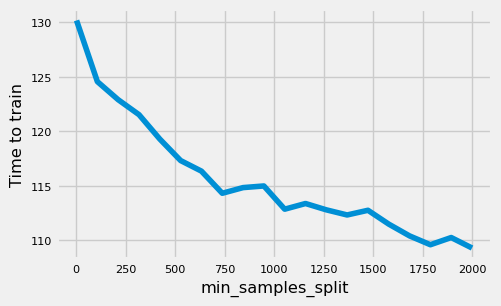

In [21]:

plt.plot( test_vals, times )
plt.xlabel( 'min_samples_split' )
plt.ylabel( 'Time to train' )
plt.show()


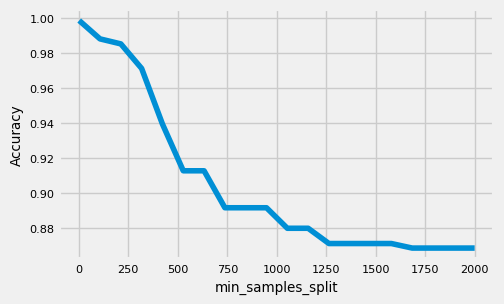

In [22]:

plt.plot( test_vals, accs )
plt.xlabel( 'min_samples_split' )
plt.ylabel( 'Accuracy' )
plt.show()


In [16]:

test_vals = np.linspace( 0.0, 0.1, num=20 )
times = []
accs = []  # List of accuracy scores

for val in test_vals:
  clf = TreePredictor(
    categorical_features,
    max_depth=10,
    min_impurity_decrease=val,
    n_unique_values=2**6 )

  start = time.time()
  clf.fit( X_train, y_train )
  end = time.time()

  times.append( round( end - start, 2 ) )
  y_pred = clf.predict( X_test )
  acc = accuracy_score( y_test, y_pred )
  accs.append( acc )


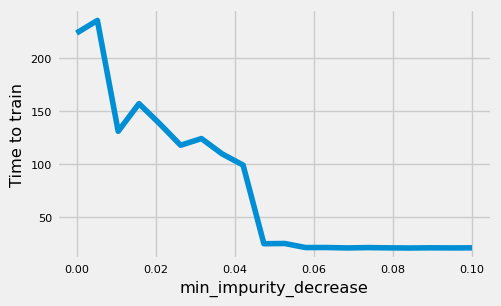

In [19]:

plt.plot( test_vals, times )
plt.xlabel( 'min_impurity_decrease' )
plt.ylabel( 'Time to train' )
plt.show()


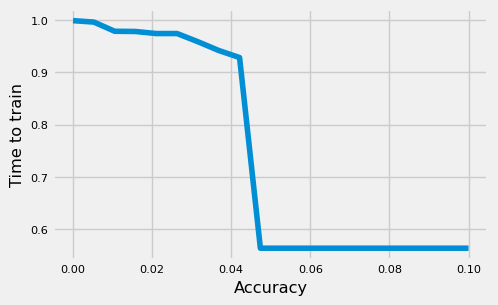

In [18]:

plt.plot( test_vals, accs )
plt.xlabel( 'min_impurity_decrease' )
plt.ylabel( 'Accuracy' )
plt.show()


In [6]:

def evaluate_tree_with_param(
  param_name: str,
  param_values: list,
  X_train: np.ndarray,
  y_train: np.ndarray,
  X_test: np.ndarray,
  y_test: np.ndarray,
  categorical_features: list[ int ],
  **tree_params
) -> tuple[ list[ float ], list[ float ], list[ float ] ]:
  times = []
  train_accuracy = []
  test_accuracy = []

  for val in param_values:
    # Create the tree predictor
    clf = TreePredictor( categorical_features, **tree_params )

    # Dynamically set the parameter value
    setattr( clf, param_name, val )

    # Train the model and measure time
    start = time.time()
    clf.fit( X_train, y_train )
    end = time.time()

    times.append( round( end - start, 2 ) )

    # Compute train accuracy
    y_pred = clf.predict( X_train )
    train_acc = accuracy_score( y_train, y_pred )
    train_accuracy.append( train_acc )

    # Test the model
    y_pred = clf.predict( X_test )
    test_acc = accuracy_score( y_test, y_pred )
    test_accuracy.append( test_acc )

  return times, train_accuracy, test_accuracy


In [8]:

param_values = np.logspace( 4, 10, num=20, base=2, dtype=int )
times, train_acc, test_acc = evaluate_tree_with_param(
  'n_unique_values',
  param_values,
  X_train,
  y_train,
  X_test,
  y_test,
  categorical_features,
  max_depth=10
)


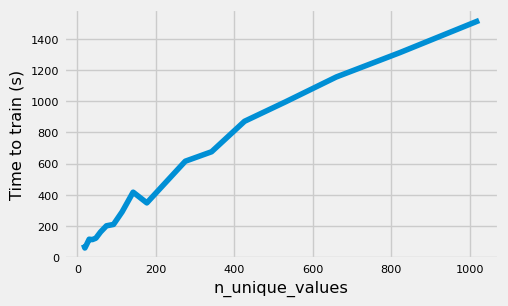

In [9]:

plt.plot( param_values, times )
plt.xlabel( 'n_unique_values' )
plt.ylabel( 'Time to train (s)' )
plt.show()


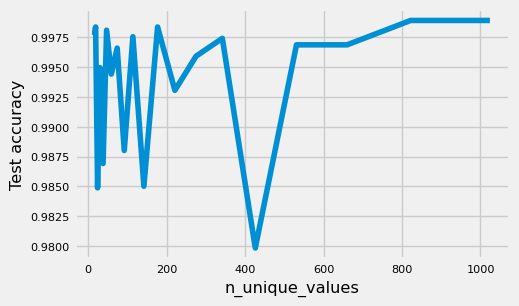

In [11]:

plt.plot( param_values, test_acc )
plt.xlabel( 'n_unique_values' )
plt.ylabel( 'Test accuracy' )
plt.show()


In [21]:

param_values = np.linspace( 5, 25, num=21, dtype=int )
times, train_acc, test_acc = evaluate_tree_with_param(
  'max_depth',
  param_values,
  X_train,
  y_train,
  X_test,
  y_test,
  categorical_features,
  n_unique_values=2**7
)


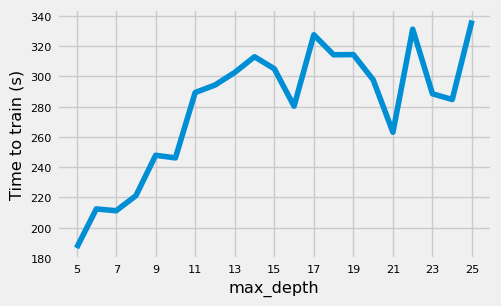

In [25]:

plt.plot( param_values, times )
plt.xlabel( 'max_depth' )
plt.xticks( ticks=[ 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25 ] )
plt.ylabel( 'Time to train (s)' )
plt.show()


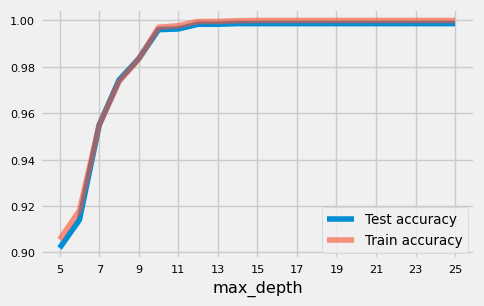

In [28]:

plt.plot( param_values, test_acc, label='Test accuracy' )
plt.plot( param_values, train_acc, alpha=.6, label='Train accuracy' )
plt.xlabel( 'max_depth' )
plt.xticks( ticks=[ 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25 ] )
plt.legend()
plt.show()


## Confusion matrices

In [9]:
from sklearn.metrics import confusion_matrix

In [13]:

clf = TreePredictor(
  categorical_features,
  min_impurity_decrease=0.07,
  n_unique_values=2**9 )

clf.fit( X_train, y_train )


In [14]:
y_pred = clf.predict( X_test )

In [15]:

print( 'Gini, minimum information gain decrease 0.07, 0-1 loss on test set:',
       zero_one_loss( y_test, y_pred ) )


Gini, minimum information gain decrease 0.07, 0-1 loss on test set: 0.11718217740836623


In [11]:

def print_confusion_matrix( y_true, y_pred ):
  tn, fp, fn, tp = confusion_matrix( y_true, y_pred ).ravel()
  d = { 'Edible classif.': [ tn, fp ], 'Poisonous classif.': [ fn, tp ] }
  df = pd.DataFrame( data=d, index=[ 'Edible label', 'Poisonous label' ] )
  return df


In [16]:
print_confusion_matrix( y_test, y_pred )

,Edible classif.,Poisonous classif.
Edible label,2613,269
Poisonous label,591,3866


In [4]:

clf = TreePredictor(
  categorical_features, splitting_criterion=Entropy(), min_samples_split=4096,
  n_unique_values=2**9 )

clf.fit( X_train, y_train )


In [5]:
y_pred = clf.predict( X_test )

In [6]:

print( 'Entropy, minimum samples for split 4096, 0-1 loss on test set:',
       zero_one_loss( y_test, y_pred ) )


Entropy, minimum samples for split 4096, 0-1 loss on test set: 0.16419130671753646


In [12]:
print_confusion_matrix( y_test, y_pred )

,Edible classif.,Poisonous classif.
Edible label,2379,380
Poisonous label,825,3755


In [18]:

clf = TreePredictor(
  categorical_features, splitting_criterion=StandardDeviation(),
  max_depth=5, n_unique_values=2**9 )

clf.fit( X_train, y_train )


In [20]:
y_pred = clf.predict( X_test )

In [21]:

print( 'Standard deviation, maximum depth 5, 0-1 loss on test set:',
       zero_one_loss( y_test, y_pred ) )


Standard deviation, maximum depth 5, 0-1 loss on test set: 0.14388881318980784


In [22]:
print_confusion_matrix( y_test, y_pred )

,Edible classif.,Poisonous classif.
Edible label,2922,774
Poisonous label,282,3361
